In [1]:
import sys
from pathlib import Path
from src.data import load_simple_price_csv

# Ensure the project root is in the path (adjust if your notebook is in a subfolder)
sys.path.append(str(Path.cwd()))

# 1. Core Configuration & Models
from src.core import Asset, Capital, FixedRiskSizer

# 2. Strategies
from src.strategies.buy_and_hold import BuyAndHoldStrategy

# 3. Engine & Analyzer
from src.engine import VectorizedEngine, PerformanceAnalyzer

# 4. Visualization
from src.visualization import plot_backtest_results, print_summary

print("✅ All imports successful!")

✅ All imports successful!


In [2]:
data = load_simple_price_csv('./data/MCFTR.csv')

In [3]:
data.head()

0
2003-02-26    335.67
2003-02-27    338.35
2003-02-28    341.52
2003-03-03    352.24
2003-03-04    348.40
Name: UNKNOWN, dtype: float64

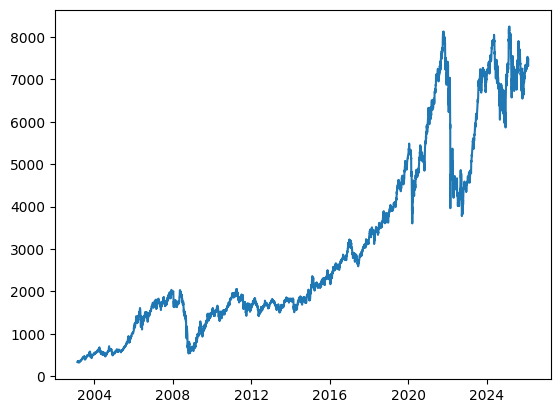

In [4]:
import matplotlib.pyplot as plt 
plt.plot(data)

In [16]:
asset = Asset(ticker="MCFTR", price_data=data, point_value=1.0, commission_rate=0.001, trading_days=252)
capital = Capital(initial_capital=100_000.0)
strategy = BuyAndHoldStrategy()

position_sizer = FixedRiskSizer(risk_target=0.15, vol_method="sma", volatility_window=252, max_leverage=1)

engine = VectorizedEngine(capital=capital, position_sizer=position_sizer) # Uses default FixedFractionSizer
execution_result = engine.run(strategy=strategy, asset=asset)
print(f"✅ Backtest complete! Final Equity: ${execution_result.equity.iloc[-1]:,.2f}")

✅ Backtest complete! Final Equity: $310,621.16


In [17]:
analyzer = PerformanceAnalyzer(capital)
metrics = analyzer.analyze(execution_result)
print_summary(name= "result", metrics=metrics)



════════════════════════════════════════════════════════════
  STRATEGY SUMMARY: result
════════════════════════════════════════════════════════════
 Total Return:        210.62%
 CAGR:                  9.24%
 Annual Volatility:    16.27%
 Sharpe Ratio:          0.57
 Sortino Ratio:        66.32
------------------------------------------------------------
 Max Drawdown:        -48.09%
 Avg Drawdown:         -3.00%
 Win Rate:             53.64%
------------------------------------------------------------
 Skew:                 -2.11
 Kurtosis:             45.51
 Tail Risk:             1.60
------------------------------------------------------------
 Gross PnL:         $214,807.04
 Net PnL:           $210,621.16
 Total Fees:        $  4,185.88
 Fee Drag Ratio:        0.02
 Cost Efficiency:       0.98
════════════════════════════════════════════════════════════



c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\visualization\plotter.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


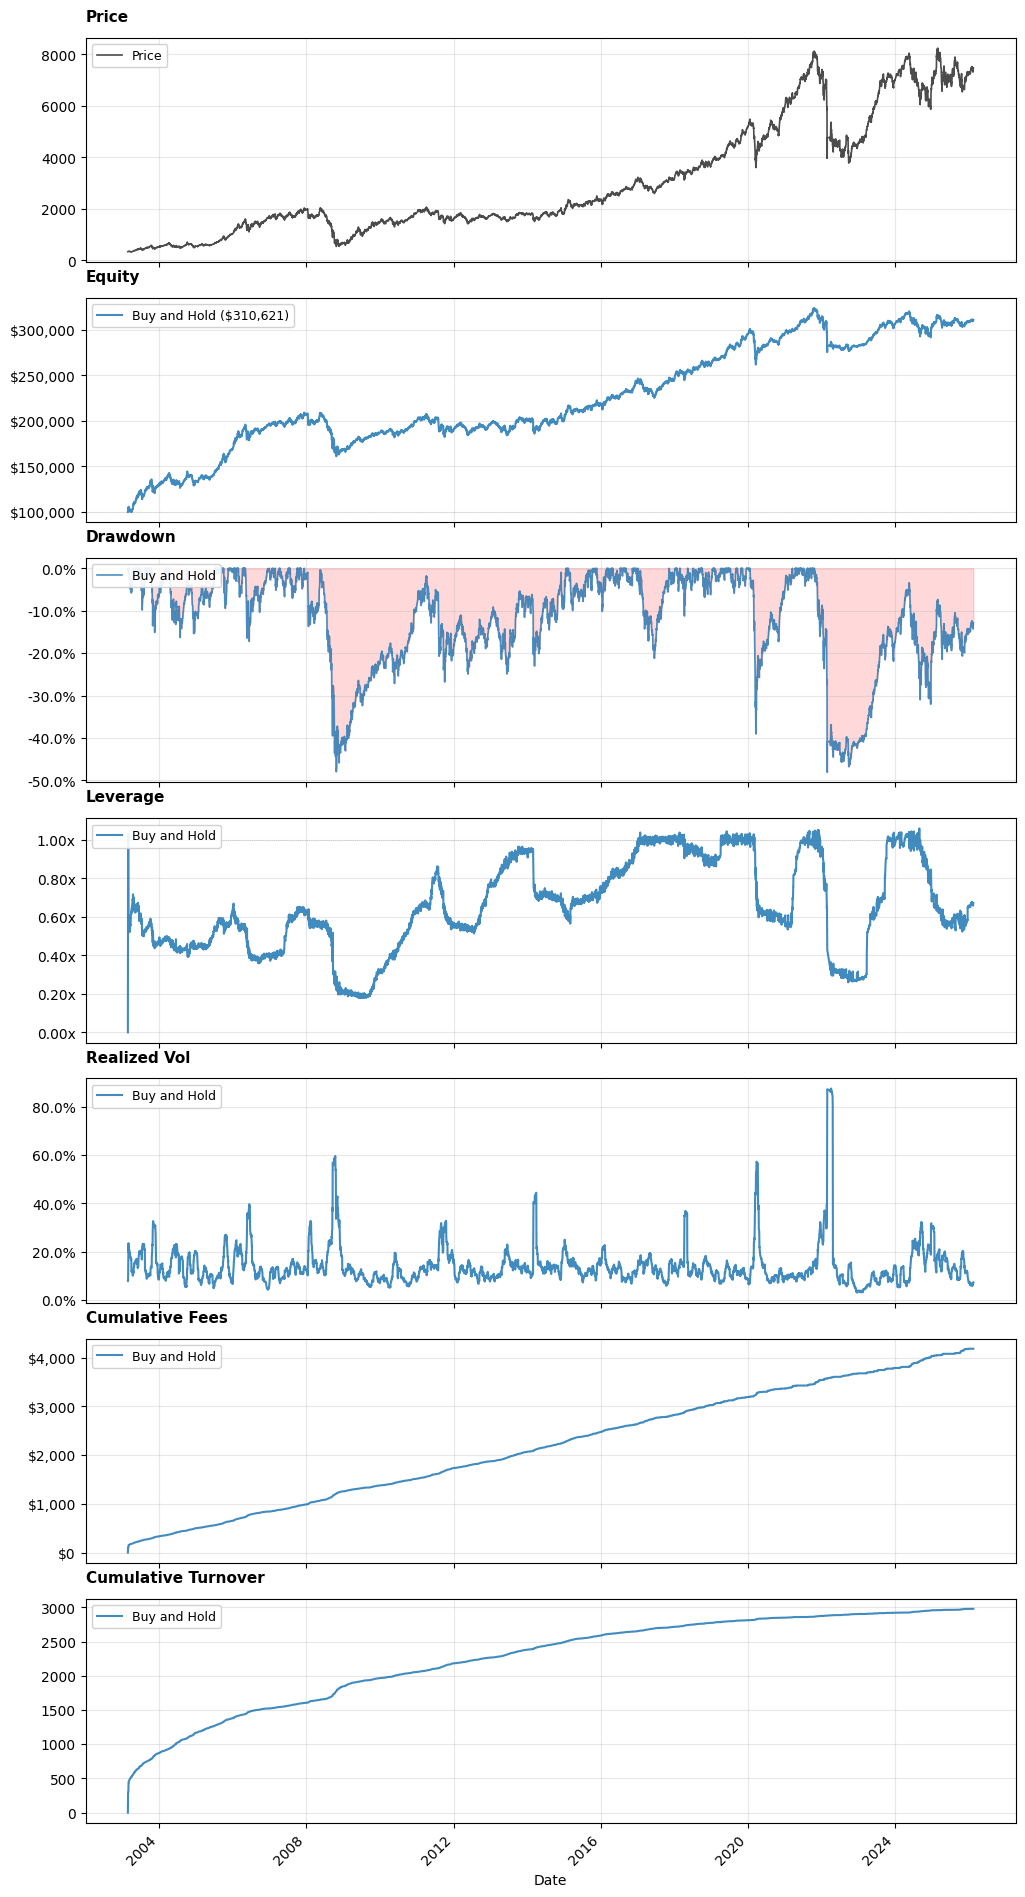

In [18]:
plot_backtest_results(
    results=execution_result,
    panels=['price', 'equity', 'drawdown', 'leverage', 'realized_vol', 'cumulative_fees', 'cumulative_turnover'],
    plot_pct=False,
    figsize_base=(12, 3)
)